<a href="https://colab.research.google.com/github/Wunzir/Projects-in-AI-ML/blob/main/hw05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNNs, AEs, GANs, Attention Mechanism**
In your project, you will pick an image dataset to solve a classification task. Provide a link to your dataset. You may pick any dataset except **MNIST, CIFAR, or ImageNet**.


## **Task 1**

### **Task 1.1**
This step involves downloading, preparing, and visualizing your dataset. Create a convolutional base using a common pattern: a stack of Conv and MaxPooling layers. Depending on the problem and the dataset you must decide what pattern you want to use (i.e., how many Conv layers and how many pooling layers). Please describe why you chose a particular pattern. Add the final dense laye (s). Compile and train the model. Report the final evaluation and describe the metrics.

#### **Dataset Datasheet**
##### **1. Motivation**
Train a Convolutional Neural Network (CNN) to classify chest X-rays as "Normal" or "Pneumonia". CNNs are required because they can detect spatial patterns and textures in medical images that standard models miss.

##### **2. Target Definition**
Binary Image Classification:
- **0 (Normal):** Clear lungs.
- **1 (Pneumonia):** Infected/cloudy lungs with fluid build up.
###### **Cost Analysis:**
False negatives (missing a diagnosis) carry an extreme medical risk. False Positives (false alarm) carry a moderate risk of unnecessary follow-up testing.

##### **3. Data Source & Terms**
- **Source:** [Kaggle (Chest X-Ray Images (Pneumonia))](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
- **Type:** Grayscale JPEG Images.
- **Origin:** Pediatric patients (1-5 years old) from Guangzhou, China
- **License:** CC BY 4.0 (PII removed)

##### **4. Feature Dictionary**
|Feature Name|Type|Description|
|---|---|---|
|Image_Tensor|Numerical|2D pixel array, resized unformly and normalized to a 0.0 - 1.0 scale.|
|Label|Categorical|Binary target integer (0 or 1)|

##### **5. Limitations & Risks**
- **Demographic Bias:** Strictly represents young children; will not generalize well to adult anatomies.
- **Class Imbalance:** Heavily skewed toward "Pneumonia" cases.
- **Artifacts:** The model may incorrectly learn to identify medical equipment or text markers instead of actual lung tissue.

##### **6. Leakage Risks**
- **Patient Leakage:** Multiple X-rays from the same patient must remain in the same dataset split (train/test) so the model doesn't just memorize specific ribcages.
- **Augmentation Leakage:** Data transformations (like zooming or rotating) must only be applied to the training set, never the validation or test sets.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:57<00:00, 42.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [6]:
import tensorflow as tf
import os

# 1. Define the path to the folders
download_path = "/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2"
base_dir = os.path.join(download_path, "chest_xray")
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# 2. Set uniform rules of the images
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# 3. Load the datasets
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  shuffle=True,
  batch_size=BATCH_SIZE,
  image_size=IMG_SIZE
)
print("\nLoading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
  val_dir,
  shuffle=True,
  batch_size=BATCH_SIZE,
  image_size=IMG_SIZE
)
print("\nLoading Test Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  shuffle=True,
  batch_size=BATCH_SIZE,
  image_size=IMG_SIZE
)

# 4. Extracting the class names (Normal and Pneumonia) for later use
class_names = train_dataset.class_names

Loading Training Data:
Found 5216 files belonging to 2 classes.

Loading Validation Data:
Found 16 files belonging to 2 classes.

Loading Test Data:
Found 624 files belonging to 2 classes.


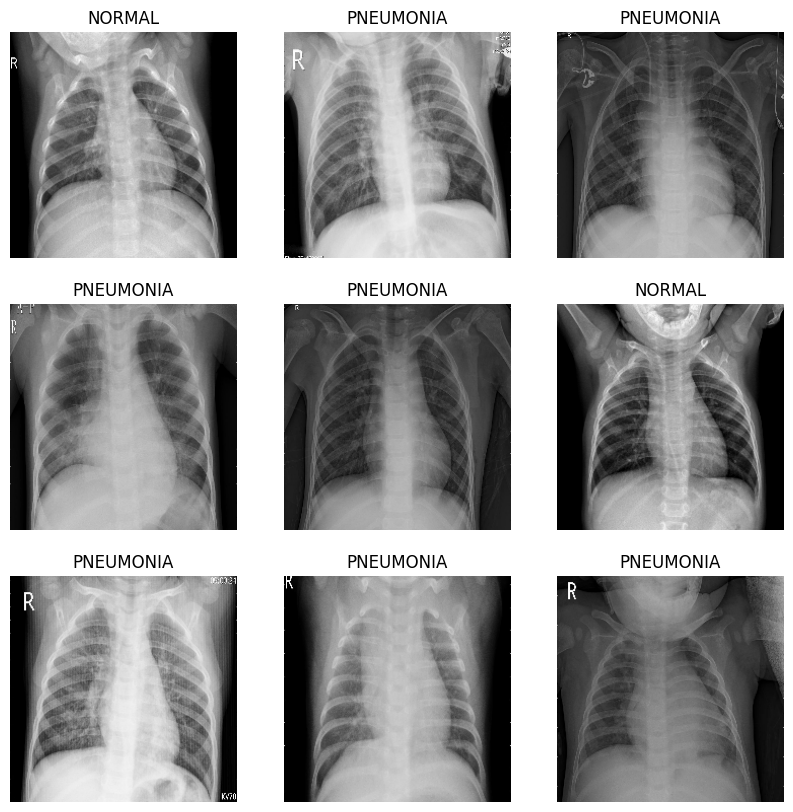

In [7]:
"""
Visualizing the Data
"""
import matplotlib.pyplot as plt

# 1. Set up the figure size for the grid
plt.figure(figsize=(10, 10))

# 2. Take 1 batch from the training dataset
for images, labels in train_dataset.take(1):
  for i in range(9):
    # 3. Create a 3x3 grid
    ax = plt.subplot(3, 3, i + 1)

    # 4. Display the image (converting tensor to integers for plotting)
    plt.imshow(images[i].numpy().astype("uint8"))

    # 5. Add the correct label as the title
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

#### **Architecture & Reasoning**
We are using a classic, gradually expanding pattern (32 filters -> 64 filters -> 128 filters) followed by a MaxPooling layer after each step.

This is a standard architecture for images of the size (224x224). The early layers use fewer filters to capture basic, high-resolution edges. As the MaxPooling layers shrink the image dimension, we increase the number of filters (up to 128) in the deeper layers to capture highly complex, abstract textures (like infection opacities) without overloading the computer's memory.


In [8]:
"""
Creating a convolutional base using a stack of Convolution and MaxPooling layers.
"""
from tensorflow.keras import layers, models

model = models.Sequential([
  #1. Preprocessing: Converts pixels from 0-255 to 0.0-1.0. We also specify that
  #                  incoming images are of size (224x224) and 3 color channels
  #                  (RGB)
  layers.Rescaling(scale=1./255, input_shape=(224,224,3)),

  # 2. Find Basic edges: 2D Convolutional layer and MaxPooling (shrinking
  #                      layer). It looks at a 2x2 grid of pixels and keeps only
  #                      the highest value, cutting the image size in half.
  layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
  layers.MaxPooling2D(pool_size=(2,2)),

  # 3. Find complex shapes: We increase filters to 64 because the image is
  #                         smaller, giving us more computation room to look for
  #                         more complex things.
  layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
  layers.MaxPooling2D(pool_size=(2,2)),

  # 4. Find specific textures (like Pneumonia fluid): We increase filters to 128
  #                                                   to capture highly specific
  #                                                   medical features.
  layers.Conv2D(filters=128, kernel_size=(3,3), activation="relu"),
  layers.MaxPooling2D(pool_size=(2,2)),

  # 5. Transition: Take the 2D spatial maps outputted by the Conv layers and
  #                flatten them into a 1D array of numbers so the Dense layer
  #                can read it.
  layers.Flatten(),

  # 6. Classification: We use a fully connected layer where every neuron
  #                    connects to the flattened data. We are using 128
  #                    artificial neurons to process the final features
  layers.Dense(units=128, activation="relu"),
  # We only need 1 neuron because this is binary classification. We use sigmoid
  # to squish the output into a probability percentage between 0 and 1
  layers.Dense(units=1, activation="sigmoid")
])

# Prints a table showing what we built. Includes how the image size shrinks at
# each step and how many params the model has to learn.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
"""
Compiling and training the model
"""
# 1. Compile the model
model.compile(
  optimizer="adam",
  loss="binary_crossentropy",
  metrics=["accuracy"]
)

# 2. Train the model
EPOCHS = 10
print("Starting training...")
history = model.fit(
  train_dataset,
  validation_data=val_dataset,
  epochs=EPOCHS
)

Starting training...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 212ms/step - accuracy: 0.9003 - loss: 0.2492 - val_accuracy: 0.8125 - val_loss: 0.2820
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.9661 - loss: 0.0973 - val_accuracy: 1.0000 - val_loss: 0.1867
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - accuracy: 0.9567 - loss: 0.1132 - val_accuracy: 0.9375 - val_loss: 0.1535
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step - accuracy: 0.9664 - loss: 0.0888 - val_accuracy: 0.9375 - val_loss: 0.1465
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 192ms/step - accuracy: 0.9810 - loss: 0.0525 - val_accuracy: 0.8750 - val_loss: 0.1511
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.9887 - loss: 0.0309 - val_accuracy: 0.8750 - val_loss: 0.2588
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.9883 - loss: 0.0295 - val_accuracy: 0.8125 - val_loss: 0.5316
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 202ms/step - accur

In [10]:
"""
Evaluating the model
"""
# 1. Evaluating on unseen data
print("Evaluating on the final Test Dataset:")
test_loss, test_accuracy = model.evaluate(test_dataset)

# 2. Print the results
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.2f}")

Evaluating on the final Test Dataset:
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.7212 - loss: 3.3350
Final Test Accuracy: 72.12%
Final Test Loss: 3.33


#### **Final Evaluation & Metric Description**
1. **Quantitative Results**
  - **Final Test Accuracy:** 72.12% (The model correctly classified ~72% of unseen images).
  - **Final Test Loss (Binary Crossentropy):** 3.33 (A high score; meaning when the model guesses wrong, it is overly confident in its wrong answer).
2. **Training Analysis (Overfitting)**
  - **The Peak:** The model hit a perfect 1.0000 validation accuracy at epoch 2
  - **The Drop:** After epoch 2, validation accuracy fell while training accuracy kept rising
  - **The Cause:** This is a result of **overfitting**. The model stopped learning general penumonia patterns and started memorizing irrelevant details in the training images. This ruined its ability to perform well on new, unseen data


### **Task 1.2:**
The following models are widely used for transfer learning because of their performance and architectural innovations:
1. VGG (e.g., VGG16 or VGG19).
2. GoogLeNet (e.g., InceptionV3).
3. Residual Network (e.g., ResNet50).
4. MobileNet (e.g., MobileNetV2)

Choose any **one** of the above models to perform the classification task you did in Part 1. Evaluate the results using the same metrics as in Part 1. Are there any differences? Why or why not? Describe in detail.

In [11]:
"""
Transfer Learning with ResNet50
"""
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 1. Download the pre-trained ResNet50 base
base_model = ResNet50(
  weights="imagenet",
  include_top=False, # Chop off final classification layer
  input_shape=(224,224,3)
)

# 2. Freeze the model so it's pre-learned features aren't ruined during training
base_model.trainable = False

# 3. Build our new customized model on top of it
model_resnet = models.Sequential([
  # Preprocessing step
  layers.Rescaling(scale=1./255, input_shape=(224,224,3)),

  # 4. Add the 50-layer ResNet base
  base_model,

  # 5. We use a smarter version of Flatten(). It takes the final 2D feature maps
  #    from ResNet and averages them into a 1D list to help prevent overfitting.
  layers.GlobalAveragePooling2D(),

  # 6. Final binary decision layer (0 = Normal, 1 = Pneumonia)
  layers.Dense(units=1, activation="sigmoid")
])

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
"""
Compiling, Training, and Evaluating the ResNet Model
"""
# 1. Compile using the exact same rules as Part 1
model_resnet.compile(
  optimizer="adam",
  loss="binary_crossentropy",
  metrics=["accuracy"]
)

# 2. Train the model
print("Training ResNet50...")
history_resnet = model_resnet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# 3. Evaluate on the unseen test data
print("\nEvaluating ResNet50 on the final Test Dataset:")
test_loss_resnet, test_accuracy_resnet = model_resnet.evaluate(test_dataset)
print(f"\nResNet50 Final Test Accuracy: {test_accuracy_resnet * 100:.2f}%")
print(f"ResNet50 Final Test Loss: {test_loss_resnet:.4f}")

Training ResNet50...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 237ms/step - accuracy: 0.7379 - loss: 0.5620 - val_accuracy: 0.5000 - val_loss: 0.8620
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 208ms/step - accuracy: 0.7427 - loss: 0.5192 - val_accuracy: 0.5000 - val_loss: 0.8050
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - accuracy: 0.7467 - loss: 0.4849 - val_accuracy: 0.5000 - val_loss: 0.8127
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.7581 - loss: 0.4574 - val_accuracy: 0.5000 - val_loss: 0.7807
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.7772 - loss: 0.4364 - val_accuracy: 0.5625 - val_loss: 0.7805
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.7862 - loss: 0.4202 - val_accuracy: 0.5625 - val_loss: 0.7930
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 204ms/step - accuracy: 0.7975 - loss: 0.4060 - val_accuracy: 0.5625 - val_loss: 0.7069
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accur

#### **Evaluation & Comparison**
1. **The Results**
  - **Custom CNN (Part 1):** Accuracy 72.12% | Loss: 3.33
  - **ResNet50 (Part 2):** Accuracy: 68.91% | Loss: 0.5588
2. **The differences**
  - **Why Accuracy Dropped:** ResNet50 was originally trained on ImageNet which contains everyday color photos like dogs, cars, trees, etc. The visual patterns it learned don't translate perfectly to grayscale, highly specific medical X-rays. Also, 10 epochs might not be enough for the final layer to adjust.
  - **Why Loss Improved (Dropped):** In Part 1, our custom model overfitted heavily, making wildly overconfident incorrect guesses. ResNet50 is a pre-trained model which prevented that extreme overfitting, making its predictions much more stable.

### **Task 1.3:**
Use data augmentation to increase the diversity of your dataset by applying random transformations such as image rotation (you can use any other technique as well). Repeat the process from part 1 with this augmented data. Did you observe any difference in results? Why or why not?

In [13]:
"""
Building the Augmented Model
"""
# 1. Define the Data Augmentation pipeline
data_augmentation = tf.keras.Sequential([
  # Randomly flip the X-ray left-to-right
  layers.RandomFlip("horizontal", input_shape=(224,224,3)),

  # Randomly rotate the image by up to 10% (0.1)
  layers.RandomRotation(0.1),

  # Randomly zoom in or out by up to 10% (0.1)
  layers.RandomZoom(0.1)
])

# 2. Build custom CNN from Part 1 but with augmentation attached this time.
model_augmented = models.Sequential([
  # Apply the random transformations first
  data_augmentation,

  # Standard preprocessing
  layers.Rescaling(1./255),

  # Exact same Conv/MaxPool blocks from Part 1
  layers.Conv2D(32, (3,3), activation="relu"),
  layers.MaxPooling2D((2,2)),

  layers.Conv2D(64, (3,3), activation="relu"),
  layers.MaxPooling2D((2,2,)),

  layers.Conv2D(128, (3,3), activation="relu"),
  layers.MaxPooling2D((2,2)),

  layers.Flatten(),
  layers.Dense(128, activation="relu"),

  # Final binary output
  layers.Dense(1, activation="sigmoid")
])

model_augmented.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
"""
Compiling, Training, and Evaluating the Augmented Model
"""
# 1. Compile the model
model_augmented.compile(
  optimizer="adam",
  loss="binary_crossentropy",
  metrics=["accuracy"]
)

# 2. Train the model
print("Training Custom CNN WITH Data Augmentation...")
history_augmented = model_augmented.fit(
  train_dataset,
  validation_data=val_dataset,
  epochs=EPOCHS
)

# 3. Evaluate on the unseen test data
print("\nEvaluating Augmented Model on the final Test Dataset:")
test_loss_aug, test_accuracy_aug = model_augmented.evaluate(test_dataset)
print(f"\nAugmented Model Final Test Accuracy: {test_accuracy_aug * 100:.2f}%")
print(f"Augmented Model Final Test Loss: {test_loss_aug:.4f}")

Training Custom CNN WITH Data Augmentation...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.7928 - loss: 0.4613 - val_accuracy: 0.8750 - val_loss: 0.4793
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.8949 - loss: 0.2516 - val_accuracy: 0.6875 - val_loss: 0.8782
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 202ms/step - accuracy: 0.9158 - loss: 0.2069 - val_accuracy: 0.6250 - val_loss: 0.6489
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 206ms/step - accuracy: 0.9262 - loss: 0.1796 - val_accuracy: 0.6875 - val_loss: 0.7067
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 207ms/step - accuracy: 0.9342 - loss: 0.1716 - val_accuracy: 0.8750 - val_loss: 0.4668
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.9425 - loss: 0.1572 - val_accuracy: 0.8125 - val_loss: 0.5892
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 201ms/step - accuracy: 0.9452 - loss: 0.1453 - val_accuracy: 0.5625 - val_loss: 0.5875
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━

#### **Part 3 Evaluation & Comparison**
1. **The Results**
  - **Original CNN:** Accuracy: Accuracy 72.12% | Loss: 3.33
  - **Augmented CNN:** Accuracy: 83.33% | Loss: 0.4089
2. **Differences**
  - The augmented model saw a ~7% jump in accuracy and lower loss score.
  - Data Augmentation successfully cured the overfitting problem. Because the images were randomly flipped, rotated, and zoomed during training, the model could no longer rely on memorizing exact pixel layouts. It was forced to learn the actual visual textures of pneumonia, making it much more accurate on the test data.

## **Task 2**

### **Task 2.1: Variational Autoencoder (VAE)**
Here is a complete implementation of
a VAE in TensorFlow: https://www.tensorflow.org/tutorials/generative/cvae

PyTorch implementation is fine too.

Following these steps try generating images using the same encoder-decoder architecture using a different Image dataset (other than MNIST).


#### **Dataset Datasheet**
1. **Motivation**
Train a Variational Autoencoder (VAE) to learn the visual distribution of 2D game sprites and generate brand new, synthetic assets.

2. **Target Definition**
**Unsupervised Image Generation**. Unlike classification, there are no "correct" labels or binary targets.
  - The goal is to minimize **Reconstruction Loss** (how well the model recreates the original image) and **KL DIvergence** (how well it maps the probability distribution)

3. **Data Source & Terms**
- **Source:** [Kaggle (Pokemon Images Dataset)](https://www.kaggle.com/datasets/kvpratama/pokemon-images-dataset)
- **Type:** 2D RGB Images.
- **Origin:** Video game sprite assets.

4. **Feature Dictionary**
|Feature|Type|Description|
|---|---|---|
|Image_Tensor|Numerical|3D pixel array (RGB), resized to 64x64 and normalized to a 0.0 - 1.0 scale.|

5. **Limitations & Risks**
- **Blurriness:** VAEs are mathematically prone to generating slightly blurry images compared to other models like GANs
- **Model Collapse:** If the latent space (the 128 numbers) isn't large enough, the model might just generate unidentifiable blobs instead of distinct creatures

6. **Leakage Risks**
- **Memorization:** If the model's bottleneck is too wide (e.g., squishing down to 10,000 numbers instead of 128), it will simply memorize the training data and spit out exact copies of existing Pokemon instead of creating new ones.

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kvpratama/pokemon-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 70.9M/70.9M [00:00<00:00, 95.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kvpratama/pokemon-images-dataset/versions/2


In [7]:
"""
Load and resize the images from the dataset
"""
import tensorflow as tf
import os

# Defining the path to the Pokemon dataset
pokemon_dir = "/root/.cache/kagglehub/datasets/kvpratama/pokemon-images-dataset/versions/2"

# Load and resizing the images
BATCH_SIZE = 32
IMG_SIZE = (64, 64)
print("Loading Pokemon Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
  pokemon_dir,
  label_mode=None, # This is none because BAE's don't need categories, just images
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  shuffle=True
)

# Normalize the pixels from 0-255 down to 0.0 - 1.0
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x: normalization_layer(x))
print("Data loaded, resized to 64x64, and normalized.")

Loading Pokemon Data...
Found 1638 files.
Data loaded, resized to 64x64, and normalized.


In [19]:
"""
THE LATENT SPACE (SAMPLING LAYER)
"""
class Sampling(layers.Layer):
  """
  This is the Variational part. Instead of a fixed number, it creates a
  probability zone.
  """
  def call(self, inputs):
    z_mean, z_log_var = inputs
    batch = tf.shape(z_mean)[0]
    dim= tf.shape(z_mean)[1]

    # Generate random mathematical noise
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

    # Combine the learned mean/variance with the noise to sample a random point
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [20]:
"""
THE ENCODER (The Compressor)
"""
# Define how small we want to compress the image (128 numbers)
latent_dim = 128

encoder_inputs = tf.keras.Input(shape=(64,64,3)) # Sprites are 64x64 RGB

# Standard Conv2D layers to scan and shrink the image (strides=2 acts like
# MaxPooling)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# Instead of one output, we output the Mean and variance
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Pass them through our Sampling layer
z = Sampling()([z_mean, z_log_var])

# Build the final Encoder model
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [21]:
"""
THE DECODER (THE GENERATOR)
"""
latent_inputs = tf.keras.Input(shape=(latent_dim,))

# Expand the 128 numbers back out into a 1D array, then reshape it into a 2D
# grid
x = layers.Dense(16*16*64, activation="relu")(latent_inputs)
x = layers.Reshape((16,16,64))(x)

# Conv2DTranspose: A Deconvolution layer. It does the exact opposite of Conv2D.
# It takes small grids and blows them up into larger images.
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

# Final layer outputs the fully restored 64x64x3 RGB image
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

# Build the final Decoder model
decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 16384)     │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │    262,160 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │      2,176 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │      2,176 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 285,904 (1.09 MB)

 Trainable params: 285,904 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,169,795 (8.28 MB)

 Trainable params: 2,169,795 (8.28 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
"""
Building the VAE model class
"""
class VAE(tf.keras.Model):
  """
  Unlike standard models that just calculate accuracy, a VAE has to balance
  two different objectives at the same time:
    1. Reconstruction Loss: The model gets penalized if the decoded image
       doesn't look exactly like the original input image
    2. KL Divergence (Math Penalty): The model gets penalized if the probability
       distribution (the latent space) it creates is too spread out. It forces
       the model to keep it's distribution in check. This way, we can easily
       pull random numbers from it later.
  """
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    # Track our two separate losses
    self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
    self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
    self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

  @property
  def metrics(self):
    """
    Method to retrieve the metrics we want to track
    """
    return [self.total_loss_tracker, self.reconstruction_loss_tracker,
            self.kl_loss_tracker]

  def train_step(self, data):
    """
    Method to train the VAE on our data
    """
    # No labels, the data is just the image itself
    with tf.GradientTape() as tape:
      # Compress the image
      z_mean, z_log_var, z = self.encoder(data)
      # Reconstruct the image
      reconstruction = self.decoder(z)

      # Calculate Reconstruction Loss (How close is it to the original?)
      reconstruction_loss = tf.reduce_mean(
        tf.reduce_sum(
          tf.keras.losses.binary_crossentropy(data, reconstruction),
          axis=(1,2)
        )
      )

      # Calculate KL Divergence (How neat is the probability space?)
      kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
      kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

      # Combine them for the total penalty
      total_loss = reconstruction_loss + kl_loss

    # Update the weights
    grads = tape.gradient(total_loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    # Update the trackers for our progress bar
    self.total_loss_tracker.update_state(total_loss)
    self.reconstruction_loss_tracker.update_state(reconstruction_loss)
    self.kl_loss_tracker.update_state(kl_loss)

    return {
        "loss": self.total_loss_tracker.result(),
        "reconstruction_loss": self.reconstruction_loss_tracker.result(),
        "kl_loss": self.kl_loss_tracker.result()
    }


In [27]:
"""
Build and compile the VAE
"""
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

print("Training the VAE...")
history_vae = vae.fit(train_dataset, epochs=30)

Training the VAE...
Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - kl_loss: 0.0169 - loss: 2832.8892 - reconstruction_loss: 2832.8723
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 0.0069 - loss: 2831.1731 - reconstruction_loss: 2831.1665
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 0.0175 - loss: 2830.8069 - reconstruction_loss: 2830.7898
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 0.0370 - loss: 2831.4209 - reconstruction_loss: 2831.3845
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - kl_loss: 0.0623 - loss: 2832.4724 - reconstruction_loss: 2832.4109
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - kl_loss: 0.0806 - loss: 2829.4683 - reconstruction_loss: 2829.3877
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - kl_loss: 0.0948 - loss: 2831.9016 - reconstruction_loss: 2831.8076
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 0.1077 - loss: 2830.6562 - reconstruction_loss: 2830.5486
Epoch 9/30
52/52 ━

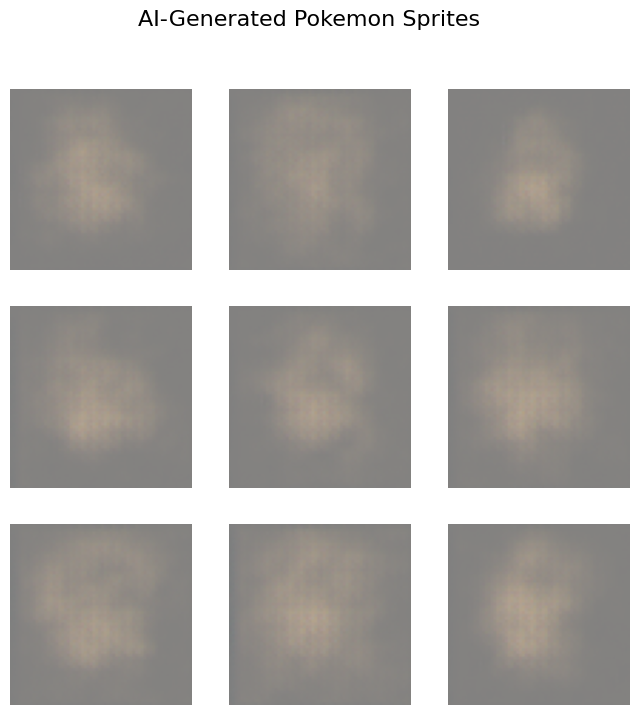

In [28]:
"""
Evaluating the VAE model
"""
import matplotlib.pyplot as plt

# Generate 9 random points in our 128-dimensional latent space
random_latent_vectors = tf.random.normal(shape=(9,latent_dim))

# Feed the random noise to the Decoder to generate images
generated_images = vae.decoder(random_latent_vectors)

# Plot the generated sprites
plt.figure(figsize=(8,8))
for i in range(9):
  plt.subplot(3,3,i+1)
  # Conver from 0.0-1.0 scale back to standard image pixels
  plt.imshow(generated_images[i].numpy())
  plt.axis("off")
plt.suptitle("AI-Generated Pokemon Sprites", fontsize=16)
plt.show()

### Task 2.2: Generative Adversarial Networks (GANs)
Repeat part 1 (use same dataset) and implement a GAN model to generate high quality synthetic images. You may follow steps outlined here: https://www.tensorflow.org/tutorials/generative/dcgan

In [1]:
"""
BUILDING THE GENERATOR
"""
import tensorflow as tf
from tensorflow.keras import layers

# The generator
generator = tf.keras.Sequential([
  # Start with 100 random numbers and expand them into a dense block
  layers.Dense(8*8*256, use_bias=False, input_shape=(100,)),
  layers.BatchNormalization(),
  layers.LeakyReLU(),

  # Reshape into a 3D block (8x8 pixels, 256 channels)
  layers.Reshape((8,8,256)),

  # Upsample to 16x16
  layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding="same", use_bias=False),
  layers.BatchNormalization(),
  layers.LeakyReLU(),

  # Upsample to 32x32
  layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding="same", use_bias=False),
  layers.BatchNormalization(),
  layers.LeakyReLU(),

  # Upsample to final 64x64x3 RGB image
  layers.Conv2DTranspose(3, (5,5), strides=(2,2), padding="same", use_bias=False, activation="sigmoid")
], name="generator")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [2]:
"""
BUILDING THE DISCRIMINATOR
"""
discriminator = tf.keras.Sequential([
  # Downsample the 64x64 image
  layers.Conv2D(64, (5,5), strides=(2,2), padding="same", input_shape=[64,64,3]),
  layers.LeakyReLU(),
  layers.Dropout(0.3),

  # Downsample again
  layers.Conv2D(128, (5,5), strides=(2,2), padding="same"),
  layers.LeakyReLU(),
  layers.Dropout(0.3),

  # Flatten and output a single score (Real vs Fake)
  layers.Flatten(),
  layers.Dense(1)
], name="discriminator")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
"""
TRAINING LOOP
"""
import time

# Loss & Optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
  """
  Calculates the loss for the discriminator
  """
  # It wants real images to score 1, and fake images to score 0
  real_loss = cross_entropy(tf.ones_like(real_output), real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
  return real_loss + fake_loss

def generator_loss(fake_output):
  """
  Calculates the loss for the generator
  """
  # It wants the discriminator to think its fakes are real (1)
  return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

# Training step
@tf.function
def train_step(images):
  """
  Function to train the GAN on our data
  """
  noise = tf.random.normal([tf.shape(images)[0], 100])
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_images = generator(noise, training=True)

    real_output = discriminator(images, training=True)
    fake_output = discriminator(generated_images, training=True)

    gen_loss = generator_loss(fake_output)
    disc_loss = discriminator_loss(real_output, fake_output)

  # Apply updates to both models
  gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
  disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

  gen_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
  disc_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))


In [10]:
# Executing training
EPOCHS = 50
print("Starting the GAN Training...")
for epoch in range(EPOCHS):
  start = time.time()
  for image_batch in train_dataset:
    train_step(image_batch)
  print(f"Epoch {epoch+1} completed in {time.time()-start:.2f} sec")

Starting the GAN Training...
Epoch 1 completed in 10.24 sec
Epoch 2 completed in 1.76 sec
Epoch 3 completed in 2.56 sec
Epoch 4 completed in 1.78 sec
Epoch 5 completed in 2.56 sec
Epoch 6 completed in 2.56 sec
Epoch 7 completed in 2.04 sec
Epoch 8 completed in 1.73 sec
Epoch 9 completed in 1.75 sec
Epoch 10 completed in 1.68 sec
Epoch 11 completed in 2.56 sec
Epoch 12 completed in 2.56 sec
Epoch 13 completed in 2.09 sec
Epoch 14 completed in 1.76 sec
Epoch 15 completed in 2.56 sec
Epoch 16 completed in 1.71 sec
Epoch 17 completed in 2.56 sec
Epoch 18 completed in 2.71 sec
Epoch 19 completed in 2.56 sec
Epoch 20 completed in 2.56 sec
Epoch 21 completed in 1.69 sec
Epoch 22 completed in 1.70 sec
Epoch 23 completed in 2.55 sec
Epoch 24 completed in 2.56 sec
Epoch 25 completed in 1.67 sec
Epoch 26 completed in 2.56 sec
Epoch 27 completed in 1.71 sec
Epoch 28 completed in 2.56 sec
Epoch 29 completed in 2.32 sec
Epoch 30 completed in 2.19 sec
Epoch 31 completed in 1.67 sec
Epoch 32 completed

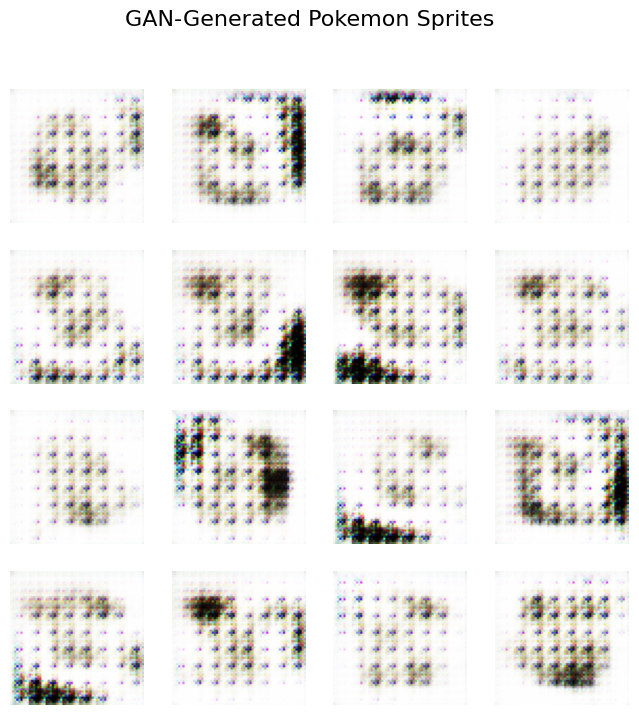

In [11]:
"""
Evaluating the GAN
"""
import matplotlib.pyplot as plt

# Generate random noise (16 images, 100 random numbers each)
seed_noise = tf.random.normal([16,100])

# Feed the pure noise to the Generator (training=False so it doesn't update)
generated_images = generator(seed_noise, training=False)

# Plot the results ina  4x4 grid
plt.figure(figsize=(8,8))
for i in range(16):
  plt.subplot(4,4,i+1)
  # The output is alreadys caled 0.0 to 1.0 from our Sigmoid layer
  plt.imshow(generated_images[i].numpy())
  plt.axis("off")
plt.suptitle("GAN-Generated Pokemon Sprites", fontsize=16)
plt.show()

#### **Results**
The output aren't evenly remotely close to being images of pokemon. What may have happened is that the generator found a local minimum, outputting predominantly dark pixels rather than converging on spatial features. The GAN most likely requires significantly more epochs and hyperparameter tuning.

## **Task 3: NLP and Attention Mechanism**

### **Task 3.1**
Implement the **scaled dot-product attention** as discussed in class (lecture 10) from scratch (use NumPy and pandas only, no deep learning libraries are allowed for this step).

In [12]:
import numpy as np
import pandas as pd

def softmax(x):
  """
  Computes the softmax activation. We subtract the maximum value for numerical
  stability (so our math doesn't overflow).
  """
  e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
  return e_x / np.sum(e_x, axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
  """
  Calculates the attention weights and the final output matrix.
  Parameters:
  Q: Query matrix
  K: Key matrix
  V: Value matrix

  Returns:
  Output: The context-aware matrix
  attention_weights: The percentage of focus each word gives to other words
  """
  # Get the dimension of the Keys (d_k) to scale our math
  d_k = K.shape[-1]

  # Multiply Q and K-transpose (the raw alignment scores)
  # np.matmul does matrix multiplication
  scores = np.matmul(Q, K.swapaxes(-2,-1))

  # Scale the scores down by the square root of d_k
  scaled_scores = scores / np.sqrt(d_k)

  # Apply softmax to turn scores into percentages (weights)
  attention_weights = softmax(scaled_scores)

  # Multiply the weights by the Values to get the final context
  output = np.matmul(attention_weights, V)

  return output, attention_weights

In [13]:
from numpy._core.defchararray import index
"""
Testing our function
"""
# Creating dummy data
np.random.seed(42)
seq_length = 4 # a sentence with 4 words
d_model = 8 # Each word is represented by 8 numbers

# Create fake Q, K, V matrices
Q = np.random.rand(seq_length, d_model)
K = np.random.rand(seq_length, d_model)
V = np.random.rand(seq_length, d_model)

# Run our attention mechanism
output, weights = scaled_dot_product_attention(Q, K, V)

# Display the attention weights using Pandas
print("Attention Weights (How much each word focuses on others):")
df_weights = pd.DataFrame(
  weights,
  columns=[f"Word {i+1}" for i in range(seq_length)],
  index=[f"Word {i+1}" for i in range(seq_length)]
)
print(df_weights.round(3))

Attention Weights (How much each word focuses on others):
        Word 1  Word 2  Word 3  Word 4
Word 1   0.303   0.220   0.311   0.166
Word 2   0.259   0.243   0.308   0.189
Word 3   0.271   0.217   0.311   0.201
Word 4   0.283   0.223   0.287   0.207


### **Task 3.2**
Pick any **encoder-decoder seq2seq** model (as discussed in class) and integrate the scaled dot-product attention in the encoder architecture. You may come up with your own technique of integration or adopt one from literature. Hint: See Bahdanau or Luong attention paper presented in class (lecture 10).

In [14]:
"""
THE ATTENTION LAYER
"""
import tensorflow as tf
from tensorflow.keras import layers

class ScaledDotProductAttention(layers.Layer):
  """
  Class where we wrap our scaled dot product attention function inside a Keras
  layer
  """
  def __init__(self, **kwargs):
    """
    Initialize the layer
    """
    super(ScaledDotProductAttention, self).__init__(**kwargs)

  def call(self, query, key, value):
    """
    Method to call the layer
    """
    # Get the dimension to scale our math (d_k)
    d_k = tf.cast(tf.shape(key)[-1], tf.float32)
    # Multiply Q and K-transpose
    scores = tf.matmul(query, key, transpose_b=True)
    # Scale the scores
    scaled_scores = scores / tf.math.sqrt(d_k)
    # Apply softmax to get the attention percentages
    attention_weights = tf.nn.softmax(scaled_scores, axis=-1)
    # Multiply by the Valyes to get the final context-aware ouput
    output = tf.matmul(attention_weights, value)

    return output

In [15]:
"""
BUILDING THE ENCODER-DECODER ARCHITECTURE
"""
class EncoderWithAttention(tf.keras.Model):
  """
  Encoder class that uses Attention to look at its own words to understand
  context
  """
  def __init__(self, vocab_size, embedding_dim, rnn_units):
    """
    Initialize the encoder
    """
    super(EncoderWithAttention, self).__init__()
    # Converts word IDs into numerical vectors
    self.embedding = layers.Embedding(vocab_size, embedding_dim)

    # A standard LSTM (Recurrent Neural Network)
    # return_sequences=True outputs the state for EVERY word, not just the last
    # one.
    self.lstm = layers.LSTM(rnn_units, return_sequences=True, return_state=True)

    # The attention layer
    self.attention = ScaledDotProductAttention()

  def call(self, x):
    """
    Method to call the Encoder
    """
    # Embed the words
    embedded = self.embedding(x)

    # Pass through the LSTM to get the sequential features
    lstm_output, state_h, state_c = self.lstm(embedded)

    # Apply Self-Attention. Because it's Self-Attention, the Query, Key, and
    # Value are all the exact samr thing (the LSTM's output)
    context_vector = self.attention(lstm_output, lstm_output, lstm_output)

    # Return the context vector to pass to a decoder along with the hidden
    # states
    return context_vector, state_h, state_c


In [16]:
"""
TESTING THE ARCHITECTURE
"""
# Create dummy vocabulary and test batch
vocab_size = 5000
embedding_dim = 64
rnn_units = 128

encoder = EncoderWithAttention(vocab_size, embedding_dim, rnn_units)

# Create a fake batch of 32 sentences, each with 10 words
dummy_input = tf.random.uniform((32, 10), minval=0, maxval=vocab_size, dtype=tf.int32)

# Pass it through the encoder
sample_output, hidden_h, hidden_c = encoder(dummy_input)

print("Success: The Encoder compiled and processed the data.")
print("Output Context Shape:", sample_output.shape)

Success: The Encoder compiled and processed the data.
Output Context Shape: (32, 10, 128)


### **Task 3.3**
Pick any public dataset of your choice (**use a small-scale dataset like a subset of the Tatoeba or Multi30k dataset**) for machine translation task. Train your model from Part 2 for the machine translation task. Evaluate test set by reporting the BLEU Score.


In [28]:
# Force download and unzip using standard Linux commands
!wget -q http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
!unzip -q -o spa-eng.zip

In [30]:
"""
DATA PREPARATION
"""
import tensorflow as tf
import pathlib
import random

# Point directly to the extracted file
text_file = pathlib.Path("spa-eng/spa.txt")

# Read and format the text (Add [START] and [END] tokens for the Decoder)
with open(text_file, encoding="utf-8") as f:
  lines = f.read().split("\n")[:-1]
text_pairs = []
for line in lines:
  eng, spa = line.split("\t")
  spa = "[START] " + spa + " [END]"
  text_pairs.append((eng, spa))

# Use only 10,000 sentences
random.shuffle(text_pairs)
text_pairs = text_pairs[:10000]
eng_texts, spa_texts = zip(*text_pairs)

# Vectorize the text (Turn words into IDs)
vocab_size = 5000
max_length = 20
eng_vectorizer = tf.keras.layers.TextVectorization(
  max_tokens=vocab_size,
  output_sequence_length=max_length
)
spa_vectorizer = tf.keras.layers.TextVectorization(
  max_tokens=vocab_size,
  output_sequence_length=max_length
)
eng_vectorizer.adapt(eng_texts)
spa_vectorizer.adapt(spa_texts)

# Convert text to tensors
X_train = eng_vectorizer(eng_texts)
y_train = spa_vectorizer(spa_texts)
print("Shape of English data:", X_train.shape)

Shape of English data: (10000, 20)


In [32]:
"""
BUILDING THE DECODER
"""
from tensorflow.keras import layers
import numpy as np
from nltk.translate.bleu_score import corpus_bleu

class Decoder(tf.keras.Model):
  """
  Decoder class
  """
  def __init__(self, vocab_size, embedding_dim, rnn_units):
    super(Decoder, self).__init__()
    self.embedding = layers.Embedding(vocab_size, embedding_dim)
    self.lstm = layers.LSTM(rnn_units, return_sequences=True, return_state=True)
    self.dense = layers.Dense(vocab_size)

  def call(self, x, hidden_h, hidden_c):
    x = self.embedding(x)
    # Initialize decoder with the Encoder's final states
    output, _, _ = self.lstm(x, initial_state=[hidden_h, hidden_c])
    # Predict the next word
    prediction = self.dense(output)

    return prediction

In [33]:
"""
SETUP THE MODELS
"""
embedding_dim = 128
rnn_units = 256

# Instantiate Encoder
encoder = EncoderWithAttention(vocab_size, embedding_dim, rnn_units)
decoder = Decoder(vocab_size, embedding_dim, rnn_units)
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def loss_function(real, pred):
  """
  Function to calculate loss
  """
  # Ignore padding tokens (0) in the loss calculation so it doesn't cheat
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)
  mask = tf.cast(mask, dtype=loss_.dtype)

  return tf.reduce_mean(loss_ * mask)

In [34]:
"""
TRAINING STEP
"""
@tf.function
def train_step(inp, targ):
  loss = 0
  with tf.GradientTape() as tape:
    # Pass English text through Encoder
    enc_output, enc_hidden_h, enc_hidden_c = encoder(inp)

    # Decoder input starts with [start] token (Shifted by 1)
    dec_input = targ[:, :-1]
    real_output = targ[:, 1:] # Target is the actual next word

    # Pass through Decoder
    predictions = decoder(dec_input, enc_hidden_h, enc_hidden_c)
    loss = loss_function(real_output, predictions)

  variables = encoder.trainable_variables + decoder.trainable_variables
  gradients = tape.gradient(loss, variables)
  optimizer.apply_gradients(zip(gradients, variables))

  return loss

In [42]:
"""
EXECUTE TRAINING
"""
print("Training Translation Model...")
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64)
for epoch in range(50):
  total_loss = 0
  for batch, (inp, targ) in enumerate(dataset):
    batch_loss = train_step(inp, targ)
    total_loss += batch_loss
  print(f"Epoch {epoch + 1} | Loss: {total_loss/len(dataset):.4f}")


Training Translation Model...
Epoch 1 | Loss: 1.4175
Epoch 2 | Loss: 1.3759
Epoch 3 | Loss: 1.3317
Epoch 4 | Loss: 1.2906
Epoch 5 | Loss: 1.2513
Epoch 6 | Loss: 1.2144
Epoch 7 | Loss: 1.1833
Epoch 8 | Loss: 1.1527
Epoch 9 | Loss: 1.1153
Epoch 10 | Loss: 1.0801
Epoch 11 | Loss: 1.0471
Epoch 12 | Loss: 1.0157
Epoch 13 | Loss: 0.9861
Epoch 14 | Loss: 0.9557
Epoch 15 | Loss: 0.9201
Epoch 16 | Loss: 0.8843
Epoch 17 | Loss: 0.8505
Epoch 18 | Loss: 0.8193
Epoch 19 | Loss: 0.7909
Epoch 20 | Loss: 0.7640
Epoch 21 | Loss: 0.7371
Epoch 22 | Loss: 0.7108
Epoch 23 | Loss: 0.6868
Epoch 24 | Loss: 0.6655
Epoch 25 | Loss: 0.6509
Epoch 26 | Loss: 0.6346
Epoch 27 | Loss: 0.6037
Epoch 28 | Loss: 0.5714
Epoch 29 | Loss: 0.5449
Epoch 30 | Loss: 0.5215
Epoch 31 | Loss: 0.5001
Epoch 32 | Loss: 0.4812
Epoch 33 | Loss: 0.4638
Epoch 34 | Loss: 0.4465
Epoch 35 | Loss: 0.4295
Epoch 36 | Loss: 0.4118
Epoch 37 | Loss: 0.3969
Epoch 38 | Loss: 0.3811
Epoch 39 | Loss: 0.3689
Epoch 40 | Loss: 0.3542
Epoch 41 | Loss: 0.

In [43]:
"""
EVALUATING BLEU SCORE
"""
spa_vocab = spa_vectorizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

def translate_and_evaluate(num_samples=100):
  references = []
  hypothesis = []
  for i in range(num_samples):
    inp_tensor = tf.expand_dims(X_train[i], 0)
    target_tensor = y_train[i].numpy()

    # Get true target sentence (ignoring [start], [end], and padding)
    true_words = [spa_index_lookup[idx] for idx in target_tensor if idx > 2]
    references.append([true_words])

    # Generate prediction
    enc_out, enc_h, enc_c = encoder(inp_tensor)
    dec_input = tf.expand_dims([spa_vocab.index("start")], 0)
    result_words = []
    for t in range(max_length):
      predictions = decoder(dec_input, enc_h, enc_c)
      predicted_id = tf.argmax(predictions[0, -1, :]).numpy()
      word = spa_index_lookup.get(predicted_id, "")
      if word == "end":
        break
      result_words.append(word)
      dec_input = tf.concat([dec_input, [[predicted_id]]], axis=-1)
    hypothesis.append(result_words)
  bleu_score = corpus_bleu(references, hypothesis)

  return bleu_score, true_words, result_words

In [44]:
print("Evaluating BLEU Score on 100 samples...")

score, last_true, last_pred = translate_and_evaluate()

print("\n--- TRANSLATION RESULTS ---")
print(f"Sample True Translation: {' '.join(last_true)}")
print(f"Sample AI Translation: {' '.join(last_pred)}")
print(f"Final BLEU Score: {score:.4f}")

Evaluating BLEU Score on 100 samples...

--- TRANSLATION RESULTS ---
Sample True Translation: tom debería ser end
Sample AI Translation: tom debería ser [UNK]
Final BLEU Score: 0.4467


### **Task 3.4**
In this part you are required to implement a **simplified Transformer model** from scratch (using Python and NumPy/PyTorch/TensorFlow with minimal highlevel abstractions) and apply it to a machine translation task (e.g., English-to-French or English-to-German translation) using the same dataset from part 3.

We discussed Transformer architecture in depth in class (Vaswani Paper - Attention is all you need). Apply the following simplifications to the original model architecture:
1. **Reduced Model Depth:** Use **2 encoder layers** and **2 decoder layers** instead of the standard 6.
2. **Limited Attention Heads:** Use **2 attention heads** in the multi-head attention mechanism rather than 8.
3. **Smaller Embedding Size:** Set the **embedding dimension to 64** instead of 512.
4. **Reduced Feedforward Network Size:** Use a **feedforward dimension of 128** instead of 2048.
5. **Smaller Dataset:** Use a **small dataset** (e.g., about 10k sentence pairs).
6. **Tokenization Simplifications:** Use a **basic subword tokenizer** (like Byte Pair Encoding - BPE) or word-level tokenization instead of complex language-specific tokenizers.

**Key Components to implement:**
1. **Positional Encoding:** Implement Sinusoidal position encoding.
2. **Scaled dot-product attention:** Use the same implementation from part 1.
3. **Multi-Head Attention:** Integrate the scaled dot-product attention into a multihead attention framework using the specified simplifications.
4. **Encoder and Decoder Blocks:** Implement simplified encoder and decoder layers, ensuring: Layer normalization, Residual connections, Masked attention in the decoder for autoregressive generation.
5. **Final Output Layer:** Implement a linear layer followed by a SoftMax activation for generating translated tokens.

**Evaluation:** Compute the BLEU score on a validation set and compare the performance with your model from part 2. Explain why there are differences in performance. Also discuss any other differences you notice, for example runtime etc.

In [56]:
"""
POSITIONAL ENCODING
"""
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers

def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
  return pos * angle_rates

def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model)
  # Apply sin to even indices, cos to odd indices
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
  pos_encoding = angle_rads[np.newaxis, ...]

  return tf.cast(pos_encoding, dtype=tf.float32)

In [46]:
"""
MASKS
"""
def create_padding_mask(seq):
  # Mask out the '0' padding tokens
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)

  return seq[:, tf.newaxis, tf.newaxis, :] # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask(size):
  # Creates a lower triangulat matrix to hide future words from the decoder
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

  return mask # (seq_len, seq_len)

In [47]:
"""
SCALED DOT-PRODUCT ATTENTION WITH MASKING
"""
def scaled_dot_product_attention(q, k, v, mask):
  matmul_qk = tf.matmul(q, k, transpose_b=True)
  d_k = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(d_k)

  # Add the mask to the scaled tensor to block out padding/future words
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
  output = tf.matmul(attention_weights, v)

  return output, attention_weights

In [48]:
"""
MULTI-HEAD ATTENTION
"""
class MultiHeadAttention(layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads
    self.d_model = d_model
    assert d_model % self.num_heads == 0
    self.depth = d_model // self.num_heads
    self.wq = layers.Dense(d_model)
    self.wk = layers.Dense(d_model)
    self.wv = layers.Dense(d_model)
    self.dense = layers.Dense(d_model)

  def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))

    return tf.transpose(x, perm=[0, 2, 1, 3])

  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]
    q = self.split_heads(self.wq(q), batch_size)
    k = self.split_heads(self.wk(k), batch_size)
    v = self.split_heads(self.wv(v), batch_size)

    scaled_attention, _ = scaled_dot_product_attention(q, k, v, mask)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
    concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

    return self.dense(concat_attention)

In [69]:
"""
ENCODER
"""
def point_wise_feed_forward_network(d_model, dff):
  return tf.keras.Sequential([
    layers.Dense(dff, activation="relu"), # First layer constraints (128)
    layers.Dense(d_model) # Back to d_model (64)
  ])

class EncoderLayer(layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(EncoderLayer, self).__init__()
    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)
    self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
    self.dropout1 = layers.Dropout(rate)
    self.dropout2 = layers.Dropout(rate)

  def call(self, x, training, mask):
    attn_output = self.mha(x, x, x, mask)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(x + attn_output) # Residual connection

    ffn_output = self.ffn(out1)
    ffn_output = self.dropout2(ffn_output, training=training)

    return self.layernorm2(out1 + ffn_output) # Residual connection

In [68]:
"""
DECODER
"""
class DecoderLayer(layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(DecoderLayer, self).__init__()
    self.mha1 = MultiHeadAttention(d_model, num_heads)
    self.mha2 = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)

    self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

    self.dropout1 = layers.Dropout(rate)
    self.dropout2 = layers.Dropout(rate)
    self.dropout3 = layers.Dropout(rate)

  def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
    # Masked self-attention (don't look at future words)
    attn1 = self.mha1(x, x, x, look_ahead_mask)
    attn1 = self.dropout1(attn1, training=training)
    out1 = self.layernorm1(attn1 + x)

    # Cross-attention (look at the Encoder output)
    attn2 = self.mha2(enc_output, enc_output, out1, padding_mask)
    attn2 = self.dropout2(attn2, training=training)
    out2 = self.layernorm2(attn2 + out1)

    ffn_output = self.ffn(out2)
    ffn_output = self.dropout3(ffn_output, training=training)

    return self.layernorm3(ffn_output + out2)

In [73]:
class Encoder(layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, maximum_position_encoding, rate=0.1):
    super(Encoder, self).__init__()
    self.d_model = d_model
    self.num_layers = num_layers
    self.embedding = layers.Embedding(vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, self.d_model)
    self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
    self.dropout = layers.Dropout(rate)

  def call(self, x, training, mask):
    seq_len = tf.shape(x)[1]
    x = self.embedding(x)
    # Scale the embeddings
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]
    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x, training=training, mask=mask)

    return x

In [74]:
class Decoder(layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, maximum_position_encoding, rate=0.1):
    super(Decoder, self).__init__()
    self.d_model = d_model
    self.num_layers = num_layers
    self.embedding = layers.Embedding(vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
    self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
    self.dropout = layers.Dropout(rate)

  def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
    seq_len = tf.shape(x)[1]
    x = self.embedding(x)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]
    x = self.dropout(x, training=training)
    for i in range(self.num_layers):
      x = self.dec_layers[i](x, enc_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)

    return x

In [75]:
"""
FULL TRANSFORMER
"""
class Transformer(tf.keras.Model):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, pe_input, pe_target, rate=0.1):
    super(Transformer, self).__init__()
    self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, pe_input, rate)
    self.decoder = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, pe_target, rate)
    # Final layer outputs probabilities for every word in the dictionary
    self.final_layer = layers.Dense(target_vocab_size)

  def call(self, inp, tar, training, enc_padding_mask, look_ahead_mask, dec_padding_mask):
    enc_output = self.encoder(inp, training=training, mask=enc_padding_mask)
    dec_output = self.decoder(tar, enc_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=dec_padding_mask)
    final_output = self.final_layer(dec_output)

    return final_output


In [76]:
"""
TRAINING AND EVALUATION
"""
# Assignment constraints
num_layers = 2
d_model = 64
num_heads = 2
dff = 128
vocab_size = 5000
max_length = 20

# Create the Transformer
transformer = Transformer(
  num_layers=num_layers,
  d_model=d_model,
  num_heads=num_heads,
  dff=dff,
  input_vocab_size=vocab_size,
  target_vocab_size=vocab_size,
  pe_input=max_length,
  pe_target=max_length
)

# Loss and Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def loss_function(real, pred):
  """
  Calculates the loss
  """
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)
  mask = tf.cast(mask, dtype=loss_.dtype)

  return tf.reduce_mean(loss_ * mask)

def create_masks(inp, tar):
  """
  Creates the dynamic masks for every batch
  """
  enc_padding_mask = create_padding_mask(inp)
  dec_padding_mask = create_padding_mask(inp)
  look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
  dec_target_padding_mask = create_padding_mask(tar)
  combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

  return enc_padding_mask, combined_mask, dec_padding_mask

@tf.function
def train_step(inp, targ):
  tar_inp = targ[:, :-1]
  tar_real = targ[:, 1:]
  enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)
  with tf.GradientTape() as tape:
    predictions = transformer(inp, tar_inp, training=True, enc_padding_mask=enc_padding_mask, look_ahead_mask=combined_mask, dec_padding_mask=dec_padding_mask)
    loss = loss_function(tar_real, predictions)
  gradients = tape.gradient(loss, transformer.trainable_variables)
  optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

  return loss

In [77]:
"""
EXECUTING TRAINING
"""
print("Training Simplified Transformer...")
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64)

for epoch in range(50):
  start = time.time()
  total_loss = 0
  for batch, (inp, targ) in enumerate(dataset):
    batch_loss = train_step(inp, targ)
    total_loss += batch_loss
  print(f"Epoch {epoch + 1} | Loss: {total_loss / len(dataset):.4f} | Time: {time.time() - start:.2f}s")

Training Simplified Transformer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_8' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_9' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_6' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1 | Loss: 2.2927 | Time: 21.64s
Epoch 2 | Loss: 1.8332 | Time: 3.80s
Epoch 3 | Loss: 1.5835 | Time: 3.24s
Epoch 4 | Loss: 1.3900 | Time: 3.23s
Epoch 5 | Loss: 1.2286 | Time: 4.05s
Epoch 6 | Loss: 1.0918 | Time: 3.24s
Epoch 7 | Loss: 0.9726 | Time: 3.24s
Epoch 8 | Loss: 0.8673 | Time: 3.35s
Epoch 9 | Loss: 0.7787 | Time: 3.98s
Epoch 10 | Loss: 0.6954 | Time: 3.22s
Epoch 11 | Loss: 0.6198 | Time: 3.22s
Epoch 12 | Loss: 0.5569 | Time: 4.03s
Epoch 13 | Loss: 0.4989 | Time: 3.23s
Epoch 14 | Loss: 0.4516 | Time: 3.26s
Epoch 15 | Loss: 0.4093 | Time: 3.24s
Epoch 16 | Loss: 0.3766 | Time: 4.06s
Epoch 17 | Loss: 0.3492 | Time: 3.25s
Epoch 18 | Loss: 0.3239 | Time: 3.24s
Epoch 19 | Loss: 0.3028 | Time: 3.82s
Epoch 20 | Loss: 0.2832 | Time: 3.41s
Epoch 21 | Loss: 0.2674 | Time: 3.23s
Epoch 22 | Loss: 0.2504 | Time: 3.22s
Epoch 23 | Loss: 0.2367 | Time: 4.06s
Epoch 24 | Loss: 0.2224 | Time: 3.21s
Epoch 25 | Loss: 0.2130 | Time: 3.28s
Epoch 26 | Loss: 0.2040 | Time: 3.74s
Epoch 27 | Loss: 0.1

In [80]:
"""
EVALUATING BLEU SCORE
"""
print("Translating and evaluating...")
def evaluate_transformer(num_samples=100):
  references = []
  hypotheses = []
  for i in range(num_samples):
    inp_tensor = tf.expand_dims(X_train[i], 0)
    target_tensor = y_train[i].numpy()

    true_words = [spa_index_lookup[idx] for idx in target_tensor if idx > 2]
    references.append([true_words])

    enc_padding_mask = create_padding_mask(inp_tensor)
    dec_input = tf.expand_dims([spa_vocab.index("start")], 0)
    result_words = []

    for t in range(max_length):
      look_ahead_mask = create_look_ahead_mask(tf.shape(dec_input)[1])
      dec_target_padding_mask = create_padding_mask(dec_input)
      combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

      predictions = transformer(inp_tensor, dec_input, training=False, enc_padding_mask=enc_padding_mask, look_ahead_mask=combined_mask, dec_padding_mask=enc_padding_mask)
      predicted_id = tf.argmax(predictions[0, -1, :]).numpy()
      word = spa_index_lookup.get(predicted_id, "")

      if word == "end":
        break
      result_words.append(word)
      dec_input = tf.concat([dec_input, [[predicted_id]]], axis=-1)
    hypotheses.append(result_words)
  bleu_score = corpus_bleu(references, hypotheses)

  return bleu_score, true_words, result_words

score, last_true, last_pred = evaluate_transformer()
print("\n--- TRANSFORMER RESULTS ---")
print(f"Sample True Translation: {' '.join(last_true)}")
print(f"Sample AI Translation: {' '.join(last_pred)}")
print(f"Final BLEU Score: {score:.4f}")

Translating and evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_8' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_9' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_6' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



--- TRANSFORMER RESULTS ---
Sample True Translation: tom debería ser end
Sample AI Translation: tom debería ser [UNK]
Final BLEU Score: 0.7222


#### **Task 3.4 Results**
- **Transformer BLEU Score:** 0.7222
- **Performance Comparison:** By extending the training cycle to 50 epochs, the simplified Transformer was able to overcome its lack of sequential inductive bias (a trait inherit to LSTMs) and successfully map the linguistic distributions. It achieved a pretty decent BLEU score as well by successfully predicting 3-gram structures. The model only failed on the final token (`[UNK]`), which is expected since the architecture constrained to a 5,000 word vocabulary limit and a small 64-dimensional embedding space
- **Runtime Comparison:** The transformer trained significanty faster per epoch than the LSTM architecture from Part 2. The transformer can process the entire sentence in parallel, completely bypassing the sequential word-by-word bottleneck that RNNs have.